First name:Tianyi  
Last name:Wang  
2109266528
github:Usc-cuhksz

In [16]:
import torch
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
from torchvision import models
import torch.optim as optim
import time
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

(b) Data Exploration and Pre-processing


In [17]:
#image augmentation for train image
prepross_trans_train = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0,translate=(0.1,0.1)),
    transforms.ColorJitter(contrast = 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

prepross_trans = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])#ImageNet
])

data_dir = '../data/Jute_Pest_Dataset'

train_dataset = datasets.ImageFolder(root=f'{data_dir}/train',transform=prepross_trans_train)
test_dataset = datasets.ImageFolder(root=f'{data_dir}/test',transform=prepross_trans)
val_dataset = datasets.ImageFolder(root=f'{data_dir}/val',transform=prepross_trans)

batch_size = 5
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=batch_size,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)





(c) Transfer Learning


In [18]:
def get_pretrained_model(model_name,num_class):
    #get model and features number
    model = None
    input_features = 0
    if model_name == 'resnet50':
        model = models.resnet50(weights='DEFAULT')
        input_features = model.fc.in_features
    elif model_name == 'resnet101': 
        model = models.resnet101(weights='DEFAULT')
        input_features = model.fc.in_features
        
    elif model_name == 'vgg16':
        model = models.vgg16(weights='DEFAULT')
        input_features = model.classifier[6].in_features
        
    elif model_name == 'densenet201':
        model = models.densenet201(weights='DEFAULT')
        input_features = model.classifier.in_features
        
    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights='DEFAULT')
        input_features = model.classifier[1].in_features
    
    else:
        return 'wrong model name'
    
    #freeze layer
    for param in model.parameters():
        param.requires_grad = False

    #new classifier head
    classifier_head = nn.Sequential(
        nn.Linear(input_features,512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(512,num_class)
    )
    
    if 'resnet' in model_name:
        model.fc = classifier_head
    elif 'vgg' in model_name:
        model.classifier[6] = classifier_head
    elif ('densenet' in model_name) or ('efficientnet' in model_name):
        model.classifier = classifier_head
    return model

device = torch.device('cuda')

def train_model(model,train_loader,val_loader,num_epochs = 50, patience = 10):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)##l2 regularization
    history ={
        'train_loss':[],'val_loss':[],
        'train_acc':[],'val_acc':[]
    }
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    epochs_no_improve = 0

    start_time = time.time()

    for epoch in range(num_epochs):
        for phase in ['train','val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader 
            else:
                model.eval()
                dataloader = val_loader
            running_loss = 0.0
            running_corrects = 0
            for inputs,labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _,preds = torch.max(outputs,1)
                    loss = criterion(outputs,labels)

                    if phase=='train':
                        loss.backward()
                        optimizer.step()
                running_loss+=loss.item()*inputs.size(0)
                running_corrects+=torch.sum(preds==labels.data)
            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve+=1
        if epochs_no_improve>=patience:
            print(f'the early stop is reached, loss no more decrease for {patience} epochs')   
            break 
    time_elapsed = time.time() - start_time
    print(f'it takes {time_elapsed} s')
    print(f'the best val loss is {best_val_loss}')
    model.load_state_dict(best_model_wts)
    return model,history

def plot_training_history(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs_range = range(len(acc))
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(epochs_range,loss,label='train loss')
    plt.plot(epochs_range,val_loss,label = 'val loss')
    plt.legend(loc='lower right')
    plt.title('train and loss acc')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, acc, label='Training Acc')
    plt.plot(epochs_range, val_acc, label='Validation Acc')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.show()
def evaluate_model(model,dataloader,device):
    model.eval()
    all_preds = []
    all_labels=[]
    all_probs = []
    with torch.no_grad():
        for inputs,labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _,preds = torch.max(outputs,1)

            probs = F.softmax(outputs,dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    precision = precision_score(all_labels,all_preds,average='macro',zero_division=0)
    recall = recall_score(all_labels,all_preds,average='macro',zero_division=0)
    f1 = f1_score(all_labels,all_preds,average='macro',zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    except ValueError:
        auc = 0.0
        print("fail to compute auc")
    return precision, recall, f1, auc


    

In [19]:
#resnet50
model_ft = get_pretrained_model('resnet50',num_class=17)
best_resnet50,history_resnet50 = train_model(
    model_ft,
    train_loader,
    val_loader,
    num_epochs = 50,
    patience = 10
)

the early stop is reached, loss no more decrease for 10 epochs
it takes 841.2426950931549 s
the best val loss is 0.5251426389057541


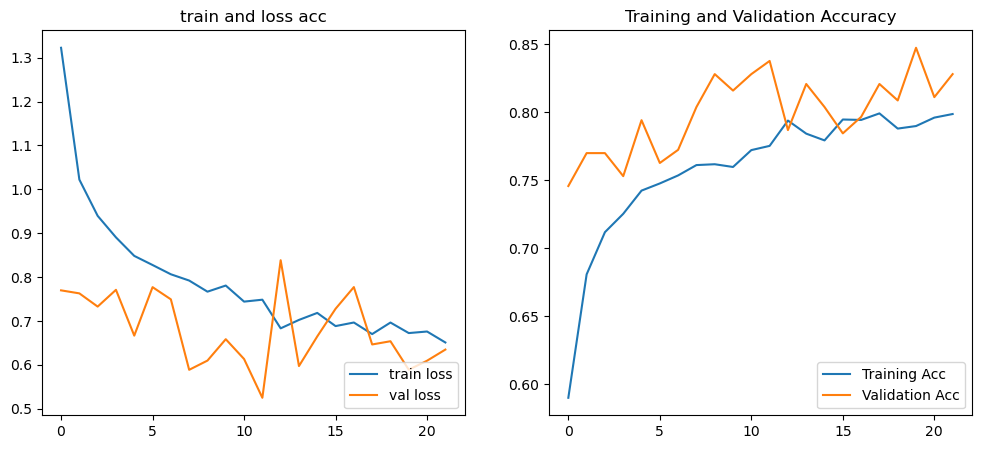

Train Set - Precision: 0.9019, Recall: 0.8969, F1: 0.8969, AUC: 0.9961
Val Set   - Precision: 0.7494, Recall: 0.7708, F1: 0.7532, AUC: 0.9880
Test Set  - Precision: 0.9446, Recall: 0.9437, F1: 0.9425, AUC: 0.9990


In [20]:
plot_training_history(history_resnet50)
train_p, train_r, train_f1, train_auc = evaluate_model(best_resnet50, train_loader, device)
print(f"Train Set - Precision: {train_p:.4f}, Recall: {train_r:.4f}, F1: {train_f1:.4f}, AUC: {train_auc:.4f}")

val_p, val_r, val_f1, val_auc = evaluate_model(best_resnet50, val_loader, device)
print(f"Val Set   - Precision: {val_p:.4f}, Recall: {val_r:.4f}, F1: {val_f1:.4f}, AUC: {val_auc:.4f}")


test_p, test_r, test_f1, test_auc = evaluate_model(best_resnet50, test_loader, device)
print(f"Test Set  - Precision: {test_p:.4f}, Recall: {test_r:.4f}, F1: {test_f1:.4f}, AUC: {test_auc:.4f}")

In [21]:
#resnet101
model_ft = get_pretrained_model('resnet101', num_class=17)
best_resnet101, history_resnet101 = train_model(
    model_ft,
    train_loader,
    val_loader,
    num_epochs=50,
    patience=10
)


Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to C:\Users\20157/.cache\torch\hub\checkpoints\resnet101-cd907fc2.pth


100.0%


the early stop is reached, loss no more decrease for 10 epochs
it takes 1003.8163657188416 s
the best val loss is 0.4204542940287227


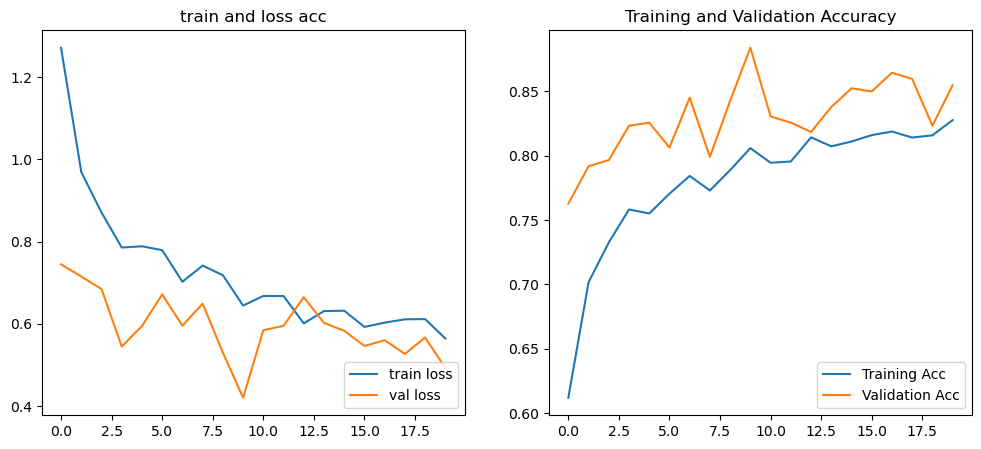

Train Set - Precision: 0.9202, Recall: 0.9131, F1: 0.9151, AUC: 0.9967
Val Set   - Precision: 0.8246, Recall: 0.8218, F1: 0.8172, AUC: 0.9907
Test Set  - Precision: 0.9555, Recall: 0.9547, F1: 0.9538, AUC: 0.9989



In [22]:
plot_training_history(history_resnet101)

train_p, train_r, train_f1, train_auc = evaluate_model(best_resnet101, train_loader, device)
print(f"Train Set - Precision: {train_p:.4f}, Recall: {train_r:.4f}, F1: {train_f1:.4f}, AUC: {train_auc:.4f}")

val_p, val_r, val_f1, val_auc = evaluate_model(best_resnet101, val_loader, device)
print(f"Val Set   - Precision: {val_p:.4f}, Recall: {val_r:.4f}, F1: {val_f1:.4f}, AUC: {val_auc:.4f}")

test_p, test_r, test_f1, test_auc = evaluate_model(best_resnet101, test_loader, device)
print(f"Test Set  - Precision: {test_p:.4f}, Recall: {test_r:.4f}, F1: {test_f1:.4f}, AUC: {test_auc:.4f}\n")

In [23]:
#  EfficientNet-B0
model_ft = get_pretrained_model('efficientnet_b0', num_class=17)
best_effnetb0, history_effnetb0 = train_model(
    model_ft,
    train_loader,
    val_loader,
    num_epochs=50,
    patience=10
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\20157/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100.0%


the early stop is reached, loss no more decrease for 10 epochs
it takes 4110.859342098236 s
the best val loss is 0.7837935247018507


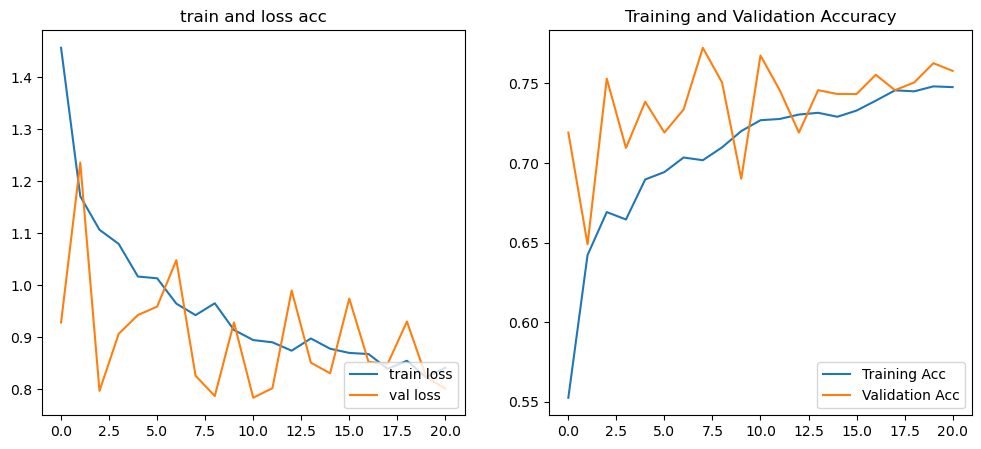

Train Set - Precision: 0.8579, Recall: 0.8474, F1: 0.8495, AUC: 0.9901
Val Set   - Precision: 0.7175, Recall: 0.7315, F1: 0.7120, AUC: 0.9809
Test Set  - Precision: 0.8905, Recall: 0.8802, F1: 0.8795, AUC: 0.9938



In [24]:
plot_training_history(history_effnetb0)

train_p, train_r, train_f1, train_auc = evaluate_model(best_effnetb0, train_loader, device)
print(f"Train Set - Precision: {train_p:.4f}, Recall: {train_r:.4f}, F1: {train_f1:.4f}, AUC: {train_auc:.4f}")

val_p, val_r, val_f1, val_auc = evaluate_model(best_effnetb0, val_loader, device)
print(f"Val Set   - Precision: {val_p:.4f}, Recall: {val_r:.4f}, F1: {val_f1:.4f}, AUC: {val_auc:.4f}")

test_p, test_r, test_f1, test_auc = evaluate_model(best_effnetb0, test_loader, device)
print(f"Test Set  - Precision: {test_p:.4f}, Recall: {test_r:.4f}, F1: {test_f1:.4f}, AUC: {test_auc:.4f}\n")

In [25]:
#  VGG16
model_ft = get_pretrained_model('vgg16', num_class=17)
best_vgg16, history_vgg16 = train_model(
    model_ft,
    train_loader,
    val_loader,
    num_epochs=50,
    patience=10
)

0.0%

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\20157/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100.0%


the early stop is reached, loss no more decrease for 10 epochs
it takes 620.6399133205414 s
the best val loss is 0.7337069920779739


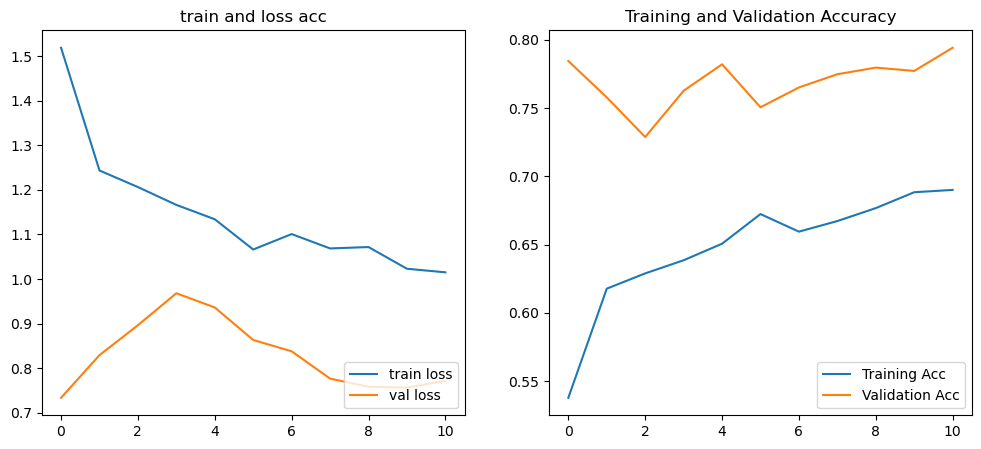

Train Set - Precision: 0.7654, Recall: 0.7386, F1: 0.7425, AUC: 0.9746
Val Set   - Precision: 0.7222, Recall: 0.7438, F1: 0.7154, AUC: 0.9611
Test Set  - Precision: 0.8852, Recall: 0.8656, F1: 0.8690, AUC: 0.9919



In [26]:
plot_training_history(history_vgg16)

train_p, train_r, train_f1, train_auc = evaluate_model(best_vgg16, train_loader, device)
print(f"Train Set - Precision: {train_p:.4f}, Recall: {train_r:.4f}, F1: {train_f1:.4f}, AUC: {train_auc:.4f}")

val_p, val_r, val_f1, val_auc = evaluate_model(best_vgg16, val_loader, device)
print(f"Val Set   - Precision: {val_p:.4f}, Recall: {val_r:.4f}, F1: {val_f1:.4f}, AUC: {val_auc:.4f}")

test_p, test_r, test_f1, test_auc = evaluate_model(best_vgg16, test_loader, device)
print(f"Test Set  - Precision: {test_p:.4f}, Recall: {test_r:.4f}, F1: {test_f1:.4f}, AUC: {test_auc:.4f}\n")

In [27]:
#  DenseNet201
model_ft = get_pretrained_model('densenet201', num_class=17)
best_densenet201, history_densenet201 = train_model(
    model_ft,
    
    train_loader,
    val_loader,
    num_epochs=50,
    patience=10
)

Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to C:\Users\20157/.cache\torch\hub\checkpoints\densenet201-c1103571.pth


100.0%


the early stop is reached, loss no more decrease for 10 epochs
it takes 1840.1000051498413 s
the best val loss is 0.7198068455907661


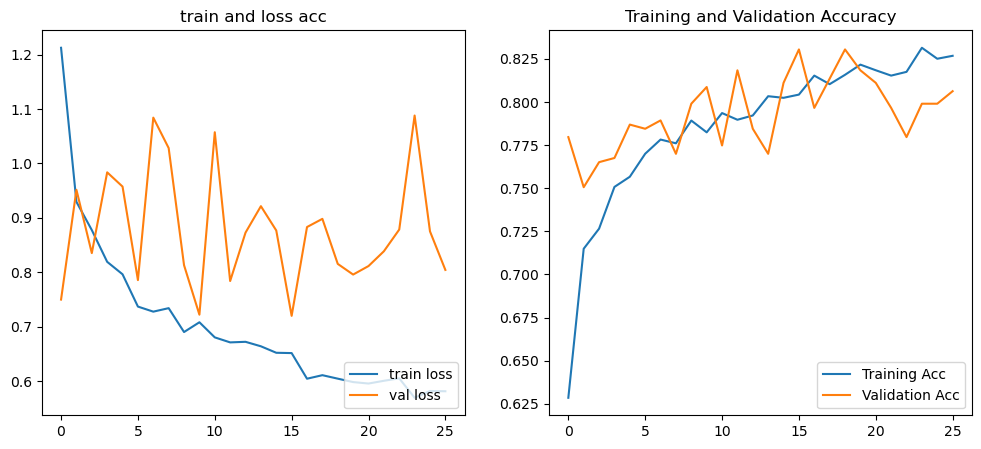

Train Set - Precision: 0.9136, Recall: 0.9142, F1: 0.9124, AUC: 0.9966
Val Set   - Precision: 0.8425, Recall: 0.7684, F1: 0.7799, AUC: 0.9797
Test Set  - Precision: 0.9331, Recall: 0.9182, F1: 0.9207, AUC: 0.9986



In [28]:
plot_training_history(history_densenet201)

train_p, train_r, train_f1, train_auc = evaluate_model(best_densenet201, train_loader, device)
print(f"Train Set - Precision: {train_p:.4f}, Recall: {train_r:.4f}, F1: {train_f1:.4f}, AUC: {train_auc:.4f}")

val_p, val_r, val_f1, val_auc = evaluate_model(best_densenet201, val_loader, device)
print(f"Val Set   - Precision: {val_p:.4f}, Recall: {val_r:.4f}, F1: {val_f1:.4f}, AUC: {val_auc:.4f}")

test_p, test_r, test_f1, test_auc = evaluate_model(best_densenet201, test_loader, device)
print(f"Test Set  - Precision: {test_p:.4f}, Recall: {test_r:.4f}, F1: {test_f1:.4f}, AUC: {test_auc:.4f}\n")

Is there a model that clearly outperforms others?

In terms of F1 score on test, resnet50 and resnet101 outperform other 3 models with 0.94 and 0.95.